In [31]:
# colab setup
colab = False

In [37]:
%load_ext autoreload
%autoreload 2
if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd drive/MyDrive/ecg_arrhythmia/
    !pip install wfdb wget numpy pandas scipy scikit-learn tensorflow matplotlib seaborn PyWavelets
    !pip install --upgrade wfdb
    !pip install neurokit2
from hyperparams import *
from tasks import *
from plot import *
from model import *
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

gridsearch_path = './gridsearch_seed/'
if not os.path.exists(gridsearch_path):
    os.makedirs(gridsearch_path)
resfile_name = 'splitseed0-39_withgroup_classweight_x1only.csv' 


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
mitdb, pwave = get_records(mitdb_dir, pwave_dir)

In [39]:
# 전체 데이터를 저장할 리스트 초기화
all_segments = []
all_features = []
all_labels = []
all_records = []
i=0
# record별 전처리
for record in tqdm(mitdb):
        print(record)
        # load ECG signal & annotations
        sig, _ = load_ECG_signal(record)
        sig = np.squeeze(sig)

        annotations = load_ECG_annotations(record=record, dir=mitdb_dir, extension='atr')
        ann_sample = annotations.sample # rpeak 근처 annotation
        symbols = annotations.symbol  # label
        dct_symbols = dict(zip(ann_sample, symbols)) # key: rpeak idx, value: label
        dct_symbols = {k: v for k, v in dct_symbols.items() if v not in ex_labels} # filter symbols
        


        # rpeak detection
        rpeaks = get_rpeaks(sig, ecg_clean_method='biosppy', ecg_peaks_method='neurokit')
        adj_rpeaks, candid_rpeaks = adjust_rpeaks(sig, rpeaks)

        # sig normalization
        scaler = StandardScaler()
        sig = scaler.fit_transform(sig.reshape(-1, 1)).flatten()

        # feature extraction (HRV)
        features = nk.hrv(adj_rpeaks, sampling_rate=360, show=False).to_numpy()
        # features = scaler.fit_transform(features.reshape(-1, 1)).reshape(1,-1)
        features = np.repeat(features, len(adj_rpeaks) - 1, axis=0)
        all_features.append(features)



        # segmetation based on rpeaks
        segments = segmentation(sig, adj_rpeaks)
        # segments = segment_heartbeats(sig, adj_rpeaks)

        # label extraction & grouping
        labels = extract_labels(adj_rpeaks, dct_symbols)
        labels = list(map(group_labels, labels))
        labels = labels[1:]  # segmentation을 하기 때문에 마지막은 제거

        # split을 위한 record 인덱스 array 생성
        record_idx = np.array([record]*len(labels)) 

        # 데이터를 리스트에 추가
        all_labels.append(labels)
        all_records.append(record_idx)
        all_segments.append(segments)   
        # i+=1
        # if i == 1:
        #     break
        


    
    
x1 = np.concatenate(all_segments, axis=0)
x2 = np.concatenate(all_features, axis=0)
y = np.concatenate(all_labels, axis=0)
records = np.concatenate(all_records, axis=0)


print("Segments(x1) Shape:", x1.shape)
print("Extracted Features(x2) Shape:", x2.shape)
print("Labels(y) Shape:", y.shape)


  0%|          | 0/48 [00:00<?, ?it/s]

109


  2%|▏         | 1/48 [00:29<23:24, 29.87s/it]

210


  4%|▍         | 2/48 [01:02<23:56, 31.23s/it]

...

217


 98%|█████████▊| 47/48 [19:57<00:22, 22.96s/it]

232


100%|██████████| 48/48 [20:14<00:00, 25.29s/it]

Segments(x1) Shape: (109748, 300)
Extracted Features(x2) Shape: (109748, 91)
Labels(y) Shape: (109748,)


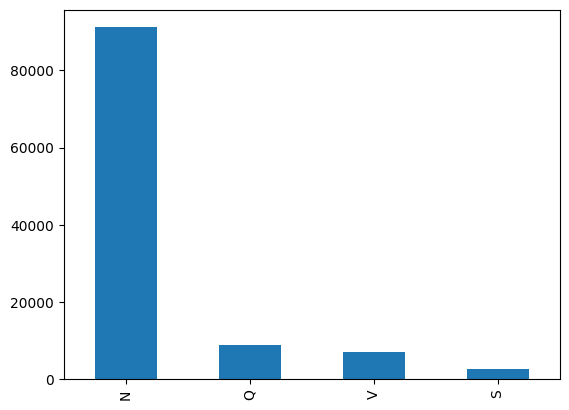

N    91080
Q     8816
V     7150
S     2702
Name: count, dtype: int64


c:\Users\hari\Desktop\workspace\ecg_arrhythmia\tasks.py:927: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hari\Desktop\workspace\ecg_arrhythmia\tasks.py:927: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hari\Desktop\workspace\ecg_arrhythmia\tasks.py:927: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hari\anaconda3\envs\py310_tf\lib\site-packages\IPython\co

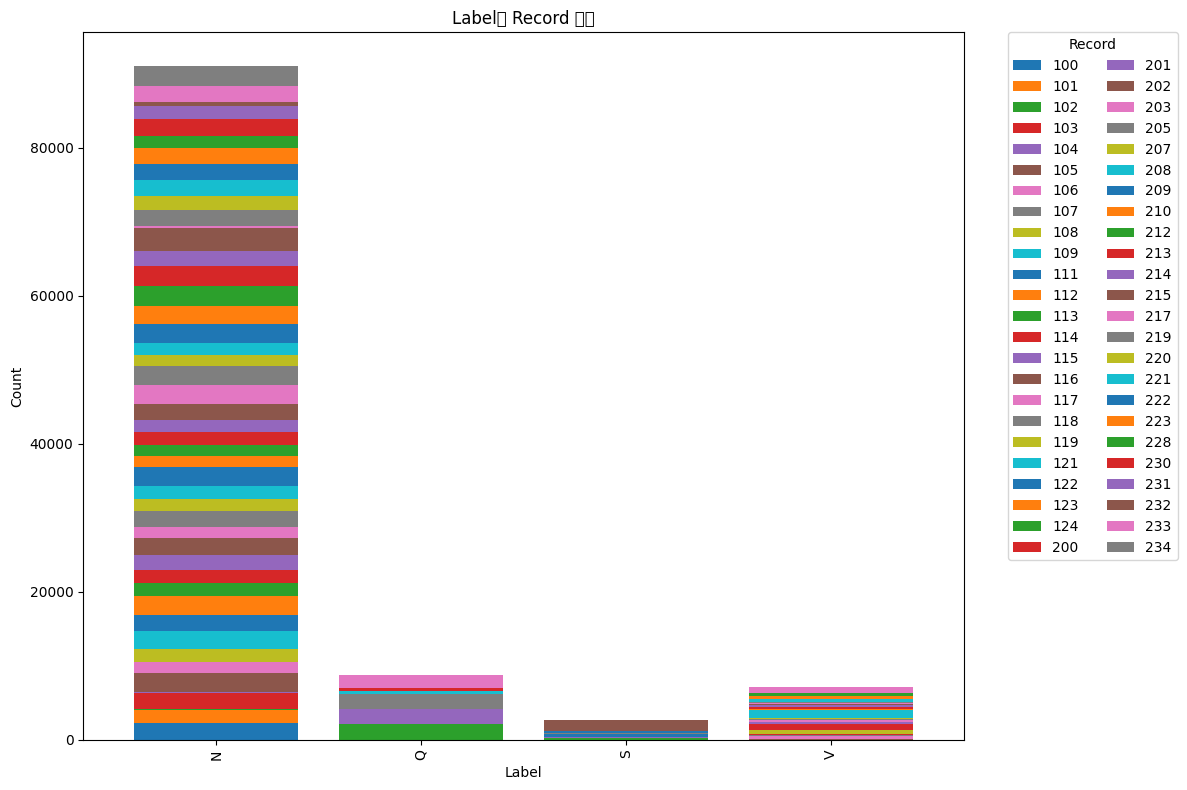

In [40]:
## plotting
label_hist(y)
label_record_hist(y, records)
# get_label_record_ratio(y, records) # label별 record 비율 desc 으로 출력

Epoch 1/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.7536 - loss: 2.2576 - val_accuracy: 0.8950 - val_loss: 0.4595
Epoch 2/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 55s 25ms/step - accuracy: 0.9195 - loss: 0.3246 - val_accuracy: 0.8940 - val_loss: 0.4564
Epoch 3/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 55s 25ms/step - accuracy: 0.9340 - loss: 0.2607 - val_accuracy: 0.8872 - val_loss: 0.4852
Epoch 4/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 55s 25ms/step - accuracy: 0.9405 - loss: 0.2329 - val_accuracy: 0.9468 - val_loss: 0.3749
Epoch 5/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 55s 24ms/step - accuracy: 0.9466 - loss: 0.2189 - val_accuracy: 0.9384 - val_loss: 0.2948
Epoch 6/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 55s 25ms/step - accuracy: 0.9509 - loss: 0.2046 - val_accuracy: 0.8711 - val_loss: 0.4227
Epoch 7/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - accuracy: 0.9522 - loss: 0.1963 - val_accuracy: 0.9382 - val_loss: 0.3273
Epoch 8/50
2233/2233 ━━━━━━━━━━━━━━━━━━━━ 55s 25ms/step - accuracy: 0.9530 -

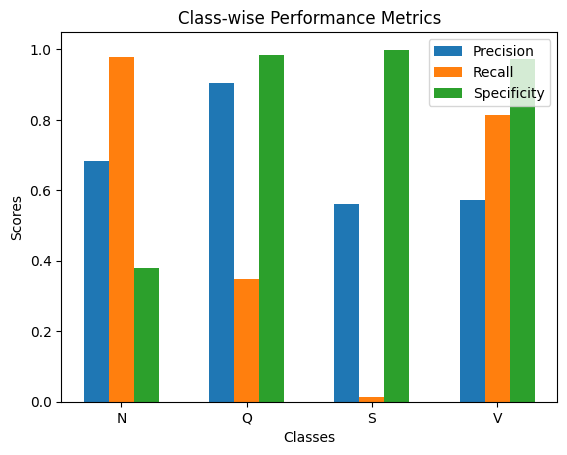

Epoch 1/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 64s 26ms/step - accuracy: 0.7311 - loss: 2.1625 - val_accuracy: 0.8807 - val_loss: 0.5089
Epoch 2/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 63s 27ms/step - accuracy: 0.9249 - loss: 0.3413 - val_accuracy: 0.8868 - val_loss: 0.4825
Epoch 3/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 63s 26ms/step - accuracy: 0.9376 - loss: 0.2776 - val_accuracy: 0.8968 - val_loss: 0.4783
Epoch 4/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 62s 26ms/step - accuracy: 0.9416 - loss: 0.2528 - val_accuracy: 0.8782 - val_loss: 0.4346
Epoch 5/50
2366/2366 ━━━━━━━━━━━━━━━━━━━━ 64s 27ms/step - accuracy: 0.9488 - loss: 0.2304 - val_accuracy: 0.9117 - val_loss: 0.4002
Epoch 6/50
 818/2366 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9537 - loss: 0.2166

KeyboardInterrupt: 

In [41]:
## X1only

# metric_df를 담을 리스트 초기화
all_metrics = []
for seed in range(40):
    file_name = f'test_seed{seed}'
    # record 기준 data split
    # combine x1, x2 for split
    x1x2 = np.hstack((x1, x2))

    # data split stratified
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    for fold, (train_val_idx, test_idx) in enumerate(sgkf.split(x1x2, y, groups=records)):
    # sgkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # for fold, (train_val_idx, test_idx) in enumerate(sgkf.split(x1x2, y)):
        break    
    x1x2_train_val = x1x2[train_val_idx]
    y_train_val = y[train_val_idx]
    records_train_val = records[train_val_idx]

    # Train/Validation 데이터를 다시 StratifiedGroupKFold로 나누기
    sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    for train_idx, val_idx in sgkf_val.split(x1x2_train_val,y_train_val, groups=records_train_val):
    # sgkf_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # for train_idx, val_idx in sgkf_val.split(x1x2_train_val,y_train_val):
        break  # 첫 번째 split을 사용하여 Train/Validation 분할

    x1_train = x1x2_train_val[train_idx][:, :x1.shape[1]]
    x2_train = x1x2_train_val[train_idx][:, x1.shape[1]:]
    x1_val = x1x2_train_val[val_idx][:, :x1.shape[1]]
    x2_val = x1x2_train_val[val_idx][:, x1.shape[1]:]
    x1_test = x1x2[test_idx][:, :x1.shape[1]]
    x2_test = x1x2[test_idx][:, x1.shape[1]:]

    y_train = y_train_val[train_idx]
    y_val = y_train_val[val_idx]
    y_test = y[test_idx]

    # class weight 생성
    unique_labels = np.unique(y_train)
    # 'balanced' 모드는 각 클래스가 데이터셋에서 등장하는 비율에 반비례하도록 가중치 계산
    class_weights_array = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=unique_labels,
        y=y_train
    )

    # scikit-learn이 반환한 array를 {클래스: 가중치} 형태의 딕셔너리로 변환
    class_weights = {
        label: weight for label, weight in zip(unique_labels, class_weights_array)
    }



    # one-hot encoding
    y_train_oh, class_names = one_hot_encoder(y_train)
    y_val_oh, _ = one_hot_encoder(y_val)
    y_test_oh, _ = one_hot_encoder(y_test)
    # model initialization
    x1_shape = (x1_train.shape[1], 1)
    x2_shape = (x2_train.shape[1],)
    n_classes = y_train_oh.shape[1]
    model = CNNx1OnlyModel(x1_shape, n_classes)   
    # model training
    model.fit(x1_train, y_train_oh, x1_val, y_val_oh, y_train, class_weight=class_weights)
    # model evaluation
    test_loss, test_accuracy = model.evaluate(x1_test, y_test_oh)
    print(f"Test accuracy: {test_accuracy:.4f}")
    # prediction
    y_pred = model.predict(x1_test)
    y_test = np.argmax(y_test_oh, axis=1)  

    # get precision, recall, f1-score, specificity
    precision, recall, f1, specificity = calc_metrics(y_test, y_pred, class_names)
    global_metrics = calc_global_metrics(y_test, y_pred)

    # report
    print(classification_report(y_test, y_pred, target_names=class_names))
    # get metric df
    metric_df = get_metric_df(precision, recall, f1, specificity, class_names)
    metric_df['seed'] = seed  # 각 seed 정보 추가
    print(metric_df)
    
    # 각 반복마다 생성된 metric_df를 리스트에 저장
    all_metrics.append(metric_df)


    # histogram
    plot_metric_hist(precision, recall, specificity, class_names)

    # # data export for colab
    # if colab:
    #     df_to_csv_colab(metric_df, file_name+'.csv')
    #     dict_to_json_colab(global_metrics, file_name+'.json')
    # else:
    #     metric_df.to_csv(gridsearch_path+file_name+'.csv', index=False)
    #     with open(gridsearch_path+file_name+'.json', 'w') as f:
    #         json.dump(global_metrics, f, indent=4)

# 모든 metric_df들을 하나의 데이터프레임으로 aggregation
aggregated_metrics = pd.concat(all_metrics, ignore_index=True)
aggregated_metrics.to_csv(gridsearch_path + resfile_name, index=False)

# 예시: seed별 또는 클래스별 평균 및 표준편차 계산하여 성능 비교
# summary_metrics = aggregated_metrics.groupby('seed').agg(['mean', 'std']).reset_index()
# print(summary_metrics)

In [ ]:
# metric_df를 담을 리스트 초기화
all_metrics = []
for seed in range(40):
    file_name = f'test_seed{seed}'
    # record 기준 data split
    # combine x1, x2 for split
    x1x2 = np.hstack((x1, x2))

    # data split stratified
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    for fold, (train_val_idx, test_idx) in enumerate(sgkf.split(x1x2, y, groups=records)):
    # sgkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # for fold, (train_val_idx, test_idx) in enumerate(sgkf.split(x1x2, y)):
        break    
    x1x2_train_val = x1x2[train_val_idx]
    y_train_val = y[train_val_idx]
    records_train_val = records[train_val_idx]

    # Train/Validation 데이터를 다시 StratifiedGroupKFold로 나누기
    sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    for train_idx, val_idx in sgkf_val.split(x1x2_train_val,y_train_val, groups=records_train_val):
    # sgkf_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # for train_idx, val_idx in sgkf_val.split(x1x2_train_val,y_train_val):
        break  # 첫 번째 split을 사용하여 Train/Validation 분할

    x1_train = x1x2_train_val[train_idx][:, :x1.shape[1]]
    x2_train = x1x2_train_val[train_idx][:, x1.shape[1]:]
    x1_val = x1x2_train_val[val_idx][:, :x1.shape[1]]
    x2_val = x1x2_train_val[val_idx][:, x1.shape[1]:]
    x1_test = x1x2[test_idx][:, :x1.shape[1]]
    x2_test = x1x2[test_idx][:, x1.shape[1]:]

    y_train = y_train_val[train_idx]
    y_val = y_train_val[val_idx]
    y_test = y[test_idx]

    # class weight 생성
    unique_labels = np.unique(y_train)
    # 'balanced' 모드는 각 클래스가 데이터셋에서 등장하는 비율에 반비례하도록 가중치 계산
    class_weights_array = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=unique_labels,
        y=y_train
    )

    # scikit-learn이 반환한 array를 {클래스: 가중치} 형태의 딕셔너리로 변환
    class_weights = {
        label: weight for label, weight in zip(unique_labels, class_weights_array)
    }



    # one-hot encoding
    y_train_oh, class_names = one_hot_encoder(y_train)
    y_val_oh, _ = one_hot_encoder(y_val)
    y_test_oh, _ = one_hot_encoder(y_test)
    # model initialization
    x1_shape = (x1_train.shape[1], 1)
    x2_shape = (x2_train.shape[1],)
    n_classes = y_train_oh.shape[1]
    model = CNNModel(x1_shape, x2_shape, n_classes)   
    # model training
    model.fit([x1_train, x2_train], y_train_oh, [x1_val, x2_val], y_val_oh, y_train, class_weight=class_weights)
    # model evaluation
    test_loss, test_accuracy = model.evaluate([x1_test,x2_test], y_test_oh)
    print(f"Test accuracy: {test_accuracy:.4f}")
    # prediction
    y_pred = model.predict([x1_test, x2_test])
    y_test = np.argmax(y_test_oh, axis=1)  

    # get precision, recall, f1-score, specificity
    precision, recall, f1, specificity = calc_metrics(y_test, y_pred, class_names)
    global_metrics = calc_global_metrics(y_test, y_pred)

    # report
    print(classification_report(y_test, y_pred, target_names=class_names))
    # get metric df
    metric_df = get_metric_df(precision, recall, f1, specificity, class_names)
    metric_df['seed'] = seed  # 각 seed 정보 추가
    print(metric_df)
    
    # 각 반복마다 생성된 metric_df를 리스트에 저장
    all_metrics.append(metric_df)


    # histogram
    plot_metric_hist(precision, recall, specificity, class_names)

    # # data export for colab
    # if colab:
    #     df_to_csv_colab(metric_df, file_name+'.csv')
    #     dict_to_json_colab(global_metrics, file_name+'.json')
    # else:
    #     metric_df.to_csv(gridsearch_path+file_name+'.csv', index=False)
    #     with open(gridsearch_path+file_name+'.json', 'w') as f:
    #         json.dump(global_metrics, f, indent=4)

# 모든 metric_df들을 하나의 데이터프레임으로 aggregation
aggregated_metrics = pd.concat(all_metrics, ignore_index=True)
aggregated_metrics.to_csv(gridsearch_path + resfile_name, index=False)

# 예시: seed별 또는 클래스별 평균 및 표준편차 계산하여 성능 비교
# summary_metrics = aggregated_metrics.groupby('seed').agg(['mean', 'std']).reset_index()
# print(summary_metrics)

In [28]:
aggregated_metrics.groupby('Class').mean()


,Precision,Recall,F1-Score,Specificity,seed
Class,,,,,
N,0.874426,0.918488,0.889188,0.380853,19.5
Q,0.431831,0.277920,0.272001,0.967616,19.5
S,0.148317,0.084047,0.060534,0.985098,19.5
V,0.534539,0.341023,0.323115,0.968104,19.5


In [29]:
aggregated_metrics.groupby('Class').max()

,Precision,Recall,F1-Score,Specificity,seed
Class,,,,,
N,0.990592,0.999203,0.973306,0.813648,39
Q,1.000000,0.996644,0.954545,1.000000,39
S,1.000000,0.629412,0.470120,1.000000,39
V,0.990741,0.893471,0.767336,0.999943,39


In [30]:
aggregated_metrics.groupby('Class').min()

,Precision,Recall,F1-Score,Specificity,seed
Class,,,,,
N,0.581420,0.652452,0.734686,0.010603,0
Q,0.000000,0.000000,0.000000,0.670442,0
S,0.000000,0.000000,0.000000,0.857268,0
V,0.074719,0.011104,0.021317,0.773944,0
